# NLI Experiment Suite — Holistic vs. Atomic × BiLSTM vs. PubMedBERT

This notebook consolidates the four training notebooks (`3a`–`3d`) and the results
comparison (`3e`) into **one OOP pipeline**. Every piece of logic that was
previously copy-pasted across notebooks — datasets, the label-encoding bug fix,
the training loop, evaluation, confusion-matrix plotting, aggregation — is now
defined **once** in a small class library, then reused by configuring and
running an `Experiment` object per model.

**Structure:**
1. Setup — imports & global config
2. Core library — shared classes (fix once, use everywhere)
3. Experiment 3a — Holistic BiLSTM
4. Experiment 3b — Holistic PubMedBERT
5. Experiment 3c — Atomic BiLSTM
6. Experiment 3d — Atomic PubMedBERT
7. Results comparison — 2×2 grid

**Note on the label-encoding bug:** earlier debugging found that the `label`
column is inconsistently typed across CSVs — sometimes an int, sometimes a
numeric string (`'0'`), sometimes a class name (`'neutral'`). This is fixed
**once**, in `LabelEncoder` below, and every dataset/aggregator in this
notebook routes through it — so it can never resurface in one model's cell
while being fixed in another's.

## 0 · Setup — Imports & Global Config

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import os, re, json, time
from dataclasses import dataclass, field
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader as TorchDataLoader
from torch.nn.utils.rnn import pad_sequence

from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    accuracy_score, matthews_corrcoef,
)
from scipy.stats import chi2

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)

DATA_DIR  = "data"
DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")

LABEL_MAP = {"entailment": 0, "contradiction": 1, "neutral": 2, "fake_drug": 3}
ID2LABEL  = {v: k for k, v in LABEL_MAP.items()}
CLASSES   = [ID2LABEL[i] for i in sorted(ID2LABEL)]

print(f"Device: {DEVICE}")
print(f"Classes: {CLASSES}")

Device: cuda
Classes: ['entailment', 'contradiction', 'neutral', 'fake_drug']


## 1 · Core Library — Shared OOP Components

Everything in this section is written once and reused by all four experiments.
Debugging a dataset, the training loop, or the aggregation rule here fixes it
**everywhere it's used** — that's the whole point of pulling it out of four
near-identical notebooks.

### 1.1 Label encoding

Robust to int, numpy int, numeric-string, or class-name-string labels — this is the fix from the earlier `int(row['label'])` crashes (`ValueError` on `'neutral'`, `KeyError` on `'0'`).

In [2]:
class LabelEncoder:
    """Converts a raw 'label' cell (int, numpy int, numeric string, or class
    name like 'neutral') into its integer class id. Try-int-first, fall back
    to the name→id map — this covers every label format seen across the CSVs.
    """
    def __init__(self, label_map: dict):
        self.label_map = label_map

    def encode(self, raw):
        try:
            return int(raw)
        except (ValueError, TypeError):
            return self.label_map[raw]

    def encode_series(self, series: pd.Series) -> pd.Series:
        return series.apply(self.encode)


LABEL_ENCODER = LabelEncoder(LABEL_MAP)

### 1.2 Datasets

`NLIPairDataset` tokenizes premise/hypothesis into a shared GloVe vocabulary for the BiLSTM models. `BERTNLIDataset` tokenizes them with a HuggingFace tokenizer for the PubMedBERT models. Both route labels through `LabelEncoder`.

In [3]:
def tokenize(text, word2idx, max_len=128):
    """Whitespace/punctuation-aware lowercase tokenizer → vocab ids."""
    tokens = re.findall(r"[a-z0-9']+", str(text).lower())[:max_len]
    ids = [word2idx.get(t, 1) for t in tokens]   # 1 = <UNK>
    return ids if ids else [1]


class NLIPairDataset(Dataset):
    """Premise/hypothesis pair dataset for the Siamese BiLSTM models.
    Used by both the holistic (3a) and atomic (3c) BiLSTM experiments —
    only `max_len` and the source CSVs differ between them.
    """
    def __init__(self, df, word2idx, label_encoder=LABEL_ENCODER, max_len=128):
        self.data          = df.reset_index(drop=True)
        self.word2idx      = word2idx
        self.label_encoder = label_encoder
        self.max_len       = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row   = self.data.iloc[idx]
        p_ids = tokenize(row['premise'],    self.word2idx, self.max_len)
        h_ids = tokenize(row['hypothesis'], self.word2idx, self.max_len)
        label = self.label_encoder.encode(row['label'])
        return (torch.tensor(p_ids), torch.tensor(h_ids), torch.tensor(label))


def collate_fn(batch):
    """Pads a batch of (premise_ids, hypothesis_ids, label) triples."""
    p_seqs, h_seqs, labels = zip(*batch)
    p_lens = torch.tensor([len(s) for s in p_seqs])
    h_lens = torch.tensor([len(s) for s in h_seqs])
    p_pad  = pad_sequence(p_seqs, batch_first=True, padding_value=0)
    h_pad  = pad_sequence(h_seqs, batch_first=True, padding_value=0)
    return p_pad, p_lens, h_pad, h_lens, torch.stack(labels)


class BERTNLIDataset(Dataset):
    """Premise/hypothesis pair dataset for the PubMedBERT models.
    Used by both the holistic (3b) and atomic (3d) BERT experiments.
    """
    # Tokens always reserved for the hypothesis (+ special tokens), so
    # 'only_second' truncation never runs out of room to cut when a
    # long premise alone is close to (or over) max_len.
    MIN_HYPOTHESIS_BUDGET = 32

    def __init__(self, df, tokenizer, label_encoder=LABEL_ENCODER, max_len=256):
        self.data          = df.reset_index(drop=True)
        self.tokenizer     = tokenizer
        self.label_encoder = label_encoder
        self.max_len       = max_len

    def __len__(self):
        return len(self.data)

    def _capped_premise(self, premise_text):
        """Pre-truncates the premise so it can never eat the entire
        max_length budget on its own. Without this, 'only_second'
        truncation raises when premise + special tokens >= max_len,
        since there'd be nothing left to trim from the hypothesis.
        """
        max_premise_len = max(self.max_len - self.MIN_HYPOTHESIS_BUDGET, 1)
        premise_ids = self.tokenizer.encode(premise_text, add_special_tokens=False)
        if len(premise_ids) <= max_premise_len:
            return premise_text
        premise_ids = premise_ids[:max_premise_len]
        return self.tokenizer.decode(premise_ids)

    def __getitem__(self, idx):
        row     = self.data.iloc[idx]
        premise = self._capped_premise(str(row['premise']))
        enc = self.tokenizer(
            premise, str(row['hypothesis']),
            max_length=self.max_len, padding='max_length',
            truncation='only_second',   # never truncate the (now-capped) premise
            return_tensors='pt',
        )
        label = self.label_encoder.encode(row['label'])
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'token_type_ids': enc.get(
                'token_type_ids', torch.zeros(self.max_len, dtype=torch.long)
            ).squeeze(0),
            'label': torch.tensor(label, dtype=torch.long),
        }

### 1.3 Model — Siamese BiLSTM

InferSent-style encoder: premise and hypothesis are each mean-pooled through a shared BiLSTM, then combined as `[u, v, |u−v|, u×v]` and classified. (PubMedBERT uses `AutoModelForSequenceClassification` directly — no custom class needed there.)

In [4]:
class SiameseBiLSTM(nn.Module):
    """InferSent-style Siamese BiLSTM for sentence-pair NLI.

    Encodes premise and hypothesis independently with a shared BiLSTM,
    then classifies via [u, v, |u-v|, u*v] aggregation.
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_classes,
                 pretrained_embeddings=None, freeze_embed=False, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if pretrained_embeddings is not None:
            self.embedding.weight = nn.Parameter(
                torch.tensor(pretrained_embeddings, dtype=torch.float32),
                requires_grad=not freeze_embed,
            )
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim, num_layers=2,
            bidirectional=True, batch_first=True, dropout=dropout,
        )
        self.drop = nn.Dropout(dropout)
        enc_dim = hidden_dim * 2  # bidirectional
        self.classifier = nn.Sequential(
            nn.Linear(enc_dim * 4, 512),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(512, 128),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, n_classes),
        )

    def encode(self, ids, lengths):
        emb = self.drop(self.embedding(ids))            # [B, L, D]
        packed = nn.utils.rnn.pack_padded_sequence(
            emb, lengths.cpu().clamp(min=1), batch_first=True, enforce_sorted=False,
        )
        out, _ = self.lstm(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True)  # [B, L, 2H]
        mask = (ids != 0).float().unsqueeze(-1)          # [B, L, 1]
        out  = (out * mask).sum(1) / mask.sum(1).clamp(min=1)
        return out                                        # [B, 2H]

    def forward(self, prem_ids, prem_len, hyp_ids, hyp_len):
        u = self.encode(prem_ids, prem_len)
        v = self.encode(hyp_ids,  hyp_len)
        x = torch.cat([u, v, torch.abs(u - v), u * v], dim=-1)
        return self.classifier(self.drop(x))

### 1.4 Class weights & plotting helpers

In [5]:
def compute_class_weights(df, n_classes, device, label_encoder=LABEL_ENCODER):
    """Inverse-frequency class weights, normalized to sum to n_classes."""
    encoded = label_encoder.encode_series(df['label'])
    counts  = encoded.value_counts().sort_index()
    weights = 1.0 / counts.reindex(range(n_classes), fill_value=1).values
    weights = weights / weights.sum() * n_classes
    return torch.tensor(weights, dtype=torch.float32).to(device)


def plot_confusion(labels, preds, id2label, title):
    cm    = confusion_matrix(labels, preds)
    names = [id2label[i] for i in sorted(id2label)]
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=names, yticklabels=names, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(title.replace(' ', '_') + '.png', dpi=150)
    plt.show()


def plot_training_curves(history, epochs, model_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    er = range(1, epochs + 1)
    ax1.plot(er, history['train_loss'], label='Train')
    ax1.plot(er, history['val_loss'],   label='Val')
    ax1.set(title='Loss', xlabel='Epoch', ylabel='Loss'); ax1.legend()
    ax2.plot(er, history['val_acc'],      label='Accuracy')
    ax2.plot(er, history['val_macro_f1'], label='Macro-F1')
    ax2.set(title='Val Metrics', xlabel='Epoch', ylabel='Score'); ax2.legend()
    plt.suptitle(f'{model_name} — Training Curves', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{model_name}_curves.png', dpi=150)
    plt.show()

### 1.5 Trainers

`BaseTrainer` implements the train/eval loop once. `BiLSTMTrainer` and `BERTTrainer` only override `_step`, which knows how to unpack their model-specific batch and call `forward`. This is the piece that used to be duplicated (and separately debugged) in every notebook.

In [6]:
class BaseTrainer:
    """Generic train/eval loop, shared by every model in this notebook.
    Subclasses only need to implement `_step`, which unpacks a batch,
    runs the forward pass, and returns (logits, loss, labels).
    """
    def __init__(self, model, device, model_name):
        self.model      = model
        self.device     = device
        self.model_name = model_name
        self.history    = {"train_loss": [], "val_loss": [], "val_acc": [], "val_macro_f1": []}
        self.best_macro = 0.0
        self.best_ckpt  = f"{model_name}_best.pt"

    def _step(self, batch):
        raise NotImplementedError

    def train_epoch(self, loader, optimizer, scheduler=None):
        self.model.train()
        total_loss, correct, total = 0.0, 0, 0
        for batch in loader:
            optimizer.zero_grad()
            logits, loss, labels = self._step(batch)
            loss.backward()
            nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            optimizer.step()
            if scheduler is not None:
                scheduler.step()
            total_loss += loss.item() * len(labels)
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += len(labels)
        return total_loss / total, correct / total

    @torch.no_grad()
    def evaluate(self, loader, id2label):
        self.model.eval()
        total_loss, all_preds, all_labels = 0.0, [], []
        for batch in loader:
            logits, loss, labels = self._step(batch)
            total_loss  += loss.item() * len(labels)
            all_preds   += logits.argmax(1).cpu().tolist()
            all_labels  += labels.cpu().tolist()
        n      = len(all_labels)
        acc    = sum(p == l for p, l in zip(all_preds, all_labels)) / n
        macro  = f1_score(all_labels, all_preds, average='macro', zero_division=0)
        report = classification_report(
            all_labels, all_preds,
            target_names=[id2label[i] for i in sorted(id2label)],
            zero_division=0,
        )
        return total_loss / n, acc, macro, report, all_preds, all_labels

    def fit(self, train_loader, val_loader, optimizer, epochs, id2label,
            scheduler=None, step_scheduler_every_batch=True):
        """If step_scheduler_every_batch is False, `scheduler.step()` is
        called once per epoch instead of once per batch (e.g. CosineAnnealingLR).
        """
        batch_scheduler = scheduler if step_scheduler_every_batch else None
        for epoch in range(1, epochs + 1):
            t0 = time.time()
            tr_loss, tr_acc = self.train_epoch(train_loader, optimizer, batch_scheduler)
            v_loss, v_acc, v_macro, _, _, _ = self.evaluate(val_loader, id2label)
            if not step_scheduler_every_batch and scheduler is not None:
                scheduler.step()

            self.history["train_loss"].append(tr_loss)
            self.history["val_loss"].append(v_loss)
            self.history["val_acc"].append(v_acc)
            self.history["val_macro_f1"].append(v_macro)

            if v_macro > self.best_macro:
                self.best_macro = v_macro
                torch.save(self.model.state_dict(), self.best_ckpt)
                flag = " ← best"
            else:
                flag = ""

            print(f"Epoch {epoch:02d}/{epochs} | "
                  f"tr_loss={tr_loss:.4f} tr_acc={tr_acc:.3f} | "
                  f"val_loss={v_loss:.4f} val_acc={v_acc:.3f} val_F1={v_macro:.3f} | "
                  f"{time.time()-t0:.1f}s{flag}")

        print(f"\nBest val macro-F1: {self.best_macro:.4f}")
        return self.history

    def load_best(self):
        self.model.load_state_dict(torch.load(self.best_ckpt, map_location=self.device))
        return self


class BiLSTMTrainer(BaseTrainer):
    def __init__(self, model, criterion, device, model_name):
        super().__init__(model, device, model_name)
        self.criterion = criterion

    def _step(self, batch):
        p_ids, p_len, h_ids, h_len, labels = batch
        p_ids, p_len = p_ids.to(self.device), p_len.to(self.device)
        h_ids, h_len = h_ids.to(self.device), h_len.to(self.device)
        labels       = labels.to(self.device)
        logits = self.model(p_ids, p_len, h_ids, h_len)
        loss   = self.criterion(logits, labels)
        return logits, loss, labels


class BERTTrainer(BaseTrainer):
    def _step(self, batch):
        input_ids  = batch['input_ids'].to(self.device)
        attn_mask  = batch['attention_mask'].to(self.device)
        token_type = batch['token_type_ids'].to(self.device)
        labels     = batch['label'].to(self.device)
        out = self.model(input_ids=input_ids, attention_mask=attn_mask,
                          token_type_ids=token_type, labels=labels)
        return out.logits, out.loss, labels

### 1.6 Atomic aggregation

Maps per-triplet predictions back to a single per-response verdict: **any predicted contradiction wins**; otherwise majority vote. Used by both atomic experiments (3c, 3d).

In [7]:
class AtomicAggregator:
    """Aggregates triplet-level NLI predictions into per-response verdicts.

    Rule:
      1. Any-contradiction: if ANY triplet is predicted Contradiction → Contradiction
      2. Otherwise: majority vote over the triplet predictions
    """
    def __init__(self, id2label, label_encoder=LABEL_ENCODER):
        self.id2label      = id2label
        self.label_encoder = label_encoder
        self.contra_id     = next(k for k, v in id2label.items() if v == "contradiction")

    def aggregate(self, atomic_df, preds):
        df = atomic_df.reset_index(drop=True).copy()
        df['pred_label'] = preds

        results = []
        for (orig_id, scenario), group in df.groupby(['original_id', 'scenario']):
            true_label  = self.label_encoder.encode(group['label'].mode()[0])
            pred_labels = group['pred_label'].tolist()

            if self.contra_id in pred_labels:
                final = self.contra_id
            else:
                final = Counter(pred_labels).most_common(1)[0][0]

            results.append({
                'original_id': orig_id,
                'scenario':    scenario,
                'true_label':  true_label,
                'pred_label':  final,
                'n_triplets':  len(pred_labels),
                'pred_dist':   str(Counter(pred_labels)),
                'correct':     final == true_label,
            })
        return pd.DataFrame(results)

### 1.7 Data loading helpers & experiment configs

In [8]:
class GloveVocab:
    """Loads the shared GloVe vocab + embedding matrix used by both BiLSTM experiments."""
    def __init__(self, data_dir):
        with open(f"{data_dir}/vocab.json") as f:
            self.word2idx = json.load(f)
        self.embed_matrix = np.load(f"{data_dir}/embed_matrix.npy")
        self.vocab_size   = len(self.word2idx)


class NLIDataBundle:
    """Loads {prefix}_train/val/test.csv and prints a quick summary.
    `prefix` is 'holistic' or 'atomic'.
    """
    def __init__(self, data_dir, prefix):
        self.prefix   = prefix
        self.train_df = pd.read_csv(f"{data_dir}/{prefix}_train.csv")
        self.val_df   = pd.read_csv(f"{data_dir}/{prefix}_val.csv")
        self.test_df  = pd.read_csv(f"{data_dir}/{prefix}_test.csv")

    def summary(self):
        print(f"Train: {len(self.train_df)}  Val: {len(self.val_df)}  Test: {len(self.test_df)}")
        print("\nTrain class dist:")
        print(self.train_df['scenario'].value_counts())
        if self.prefix == "atomic":
            neutral_frac = (self.train_df['scenario'] == 'neutral').mean()
            print(f"\nNeutral fraction in train: {neutral_frac:.1%}")
            if neutral_frac < 0.10:
                print("⚠ Neutral is severely underrepresented — class weighting applied.")
        return self


@dataclass
class BiLSTMConfig:
    model_name:   str
    data_prefix:  str          # "holistic" or "atomic"
    max_len:      int
    embed_dim:    int = 100
    hidden_dim:   int = 256
    dropout:      float = 0.3
    batch_size:   int = 64
    epochs:       int = 15
    lr:           float = 3e-4
    n_classes:    int = 4
    freeze_embed: bool = False


@dataclass
class BERTConfig:
    model_name:   str
    data_prefix:  str          # "holistic" or "atomic"
    bert_model:   str = "microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext"
    max_len:      int = 256
    batch_size:   int = 16
    epochs:       int = 5
    lr:           float = 2e-5
    warmup_frac:  float = 0.1
    n_classes:    int = 4

### 1.8 Experiment classes

Each `Experiment` wires the pieces above together: load data → build loaders → build model → train → evaluate → save predictions (+ aggregate, for atomic experiments). Running one of the four notebooks below is now a single method call.

In [9]:
class BiLSTMExperiment:
    """Runs one Siamese BiLSTM experiment (holistic or atomic)."""

    def __init__(self, config: BiLSTMConfig, data_dir=DATA_DIR, device=DEVICE,
                 label_map=LABEL_MAP, id2label=ID2LABEL):
        self.config    = config
        self.data_dir  = data_dir
        self.device    = device
        self.id2label  = id2label
        self.encoder   = LabelEncoder(label_map)
        self.is_atomic = config.data_prefix == "atomic"

    def load_data(self):
        self.bundle = NLIDataBundle(self.data_dir, self.config.data_prefix).summary()
        self.vocab  = GloveVocab(self.data_dir)
        print(f"\nVocab: {self.vocab.vocab_size}   Embed matrix: {self.vocab.embed_matrix.shape}")
        return self

    def build_loaders(self):
        c = self.config
        mk_ds = lambda df: NLIPairDataset(df, self.vocab.word2idx, self.encoder, c.max_len)
        self.train_ds = mk_ds(self.bundle.train_df)
        self.val_ds   = mk_ds(self.bundle.val_df)
        self.test_ds  = mk_ds(self.bundle.test_df)

        mk_loader = lambda ds, shuffle: TorchDataLoader(
            ds, batch_size=c.batch_size, shuffle=shuffle, collate_fn=collate_fn)
        self.train_loader = mk_loader(self.train_ds, True)
        self.val_loader   = mk_loader(self.val_ds,   False)
        self.test_loader  = mk_loader(self.test_ds,  False)
        print(f"Train batches: {len(self.train_loader)}  Val batches: {len(self.val_loader)}")
        return self

    def build_model(self):
        c = self.config
        self.model = SiameseBiLSTM(
            vocab_size=self.vocab.vocab_size, embed_dim=c.embed_dim, hidden_dim=c.hidden_dim,
            n_classes=c.n_classes, pretrained_embeddings=self.vocab.embed_matrix,
            freeze_embed=c.freeze_embed, dropout=c.dropout,
        ).to(self.device)

        class_weights  = compute_class_weights(self.bundle.train_df, c.n_classes, self.device, self.encoder)
        self.criterion = nn.CrossEntropyLoss(weight=class_weights)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=c.lr)
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(self.optimizer, T_max=c.epochs)
        self.trainer   = BiLSTMTrainer(self.model, self.criterion, self.device, c.model_name)

        total_params = sum(p.numel() for p in self.model.parameters() if p.requires_grad)
        print(f"Trainable parameters: {total_params:,}")
        print(f"Class weights: {{ {', '.join(f'{self.id2label[i]}: {w:.3f}' for i, w in enumerate(class_weights.cpu()))} }}")
        return self

    def train(self):
        self.history = self.trainer.fit(
            self.train_loader, self.val_loader, self.optimizer, self.config.epochs,
            self.id2label, scheduler=self.scheduler, step_scheduler_every_batch=False,
        )
        return self

    def plot_curves(self):
        plot_training_curves(self.history, self.config.epochs, self.config.model_name)
        return self

    def evaluate_test(self):
        self.trainer.load_best()
        _, self.test_acc, self.test_macro, report, self.preds, self.labels = \
            self.trainer.evaluate(self.test_loader, self.id2label)
        tag = "TRIPLET-LEVEL" if self.is_atomic else "TEST"
        print(f"{tag}  acc={self.test_acc:.4f}  macro-F1={self.test_macro:.4f}")
        print("\nClassification Report:")
        print(report)
        title = f"{self.config.model_name} — {'Triplet-Level' if self.is_atomic else 'Test'} Confusion Matrix"
        plot_confusion(self.labels, self.preds, self.id2label, title)
        return self

    def save_predictions(self):
        name = self.config.model_name
        if self.is_atomic:
            self.test_df_out = self.bundle.test_df.copy().reset_index(drop=True)
            self.test_df_out['pred_label'] = self.preds
            self.test_df_out['true_label'] = self.labels
            self.test_df_out.to_csv(f"{name}_triplet_predictions.csv", index=False)

            aggregator  = AtomicAggregator(self.id2label, self.encoder)
            self.agg_df = aggregator.aggregate(self.bundle.test_df, self.preds)
            agg_macro   = f1_score(self.agg_df['true_label'], self.agg_df['pred_label'],
                                    average='macro', zero_division=0)
            print(f"AGGREGATED (response-level)  acc={self.agg_df['correct'].mean():.4f}  macro-F1={agg_macro:.4f}")
            print(classification_report(
                self.agg_df['true_label'], self.agg_df['pred_label'],
                target_names=[self.id2label[i] for i in sorted(self.id2label)], zero_division=0))
            plot_confusion(self.agg_df['true_label'].tolist(), self.agg_df['pred_label'].tolist(),
                            self.id2label, f"{name} — Aggregated Confusion")
            self.agg_df.to_csv(f"{name}_aggregated_predictions.csv", index=False)

            print(f"\nSaved triplet     → {name}_triplet_predictions.csv")
            print(f"Saved aggregated  → {name}_aggregated_predictions.csv")
            print(f"Avg triplets per response: {self.agg_df['n_triplets'].mean():.1f}")
            print("Per-scenario accuracy:"); print(self.agg_df.groupby('scenario')['correct'].mean().round(3))
        else:
            self.test_df_out = self.bundle.test_df.copy().reset_index(drop=True)
            self.test_df_out['pred_label']    = self.preds
            self.test_df_out['pred_scenario'] = [self.id2label[p] for p in self.preds]
            self.test_df_out['true_label']    = self.labels
            self.test_df_out['correct']       = self.test_df_out['pred_label'] == self.test_df_out['true_label']
            out_path = f"{name}_test_predictions.csv"
            self.test_df_out.to_csv(out_path, index=False)
            print(f"Predictions saved → {out_path}")
            print("\nPer-scenario accuracy:")
            print(self.test_df_out.groupby('scenario')['correct'].mean().round(3))
        return self

    def run(self):
        return (self.load_data().build_loaders().build_model()
                    .train().plot_curves().evaluate_test().save_predictions())


class BERTExperiment:
    """Runs one PubMedBERT experiment (holistic or atomic)."""

    def __init__(self, config: BERTConfig, data_dir=DATA_DIR, device=DEVICE,
                 label_map=LABEL_MAP, id2label=ID2LABEL):
        self.config    = config
        self.data_dir  = data_dir
        self.device    = device
        self.id2label  = id2label
        self.encoder   = LabelEncoder(label_map)
        self.is_atomic = config.data_prefix == "atomic"

    def load_data(self):
        self.bundle = NLIDataBundle(self.data_dir, self.config.data_prefix).summary()
        return self

    def build_model(self):
        c = self.config
        self.tokenizer = AutoTokenizer.from_pretrained(c.bert_model)
        self.model = AutoModelForSequenceClassification.from_pretrained(
            c.bert_model, num_labels=c.n_classes,
            id2label=self.id2label, label2id=LABEL_MAP,
            hidden_dropout_prob=0.1, attention_probs_dropout_prob=0.1,
        ).to(self.device)
        trainable = sum(p.numel() for p in self.model.parameters() if p.requires_grad)
        print(f"Loaded {c.bert_model}")
        print(f"Trainable parameters: {trainable:,}")
        return self

    def build_loaders(self):
        c = self.config
        mk_ds = lambda df: BERTNLIDataset(df, self.tokenizer, self.encoder, c.max_len)
        self.train_ds = mk_ds(self.bundle.train_df)
        self.val_ds   = mk_ds(self.bundle.val_df)
        self.test_ds  = mk_ds(self.bundle.test_df)

        self.train_loader = TorchDataLoader(self.train_ds, batch_size=c.batch_size, shuffle=True)
        self.val_loader   = TorchDataLoader(self.val_ds,   batch_size=c.batch_size, shuffle=False)
        self.test_loader  = TorchDataLoader(self.test_ds,  batch_size=c.batch_size, shuffle=False)
        print(f"Train batches: {len(self.train_loader)}   Val batches: {len(self.val_loader)}")

        total_steps  = len(self.train_loader) * c.epochs
        warmup_steps = int(total_steps * c.warmup_frac)
        self.optimizer = torch.optim.AdamW(self.model.parameters(), lr=c.lr, weight_decay=0.01)
        self.scheduler = get_linear_schedule_with_warmup(self.optimizer, warmup_steps, total_steps)
        print(f"Total steps: {total_steps}   Warmup steps: {warmup_steps}")

        self.trainer = BERTTrainer(self.model, self.device, c.model_name)
        return self

    def train(self):
        self.history = self.trainer.fit(
            self.train_loader, self.val_loader, self.optimizer, self.config.epochs,
            self.id2label, scheduler=self.scheduler, step_scheduler_every_batch=True,
        )
        return self

    def plot_curves(self):
        plot_training_curves(self.history, self.config.epochs, self.config.model_name)
        return self

    def evaluate_test(self):
        self.trainer.load_best()
        _, self.test_acc, self.test_macro, report, self.preds, self.labels = \
            self.trainer.evaluate(self.test_loader, self.id2label)
        tag = "TRIPLET-LEVEL" if self.is_atomic else "TEST"
        print(f"{tag}  acc={self.test_acc:.4f}  macro-F1={self.test_macro:.4f}")
        print("\nClassification Report:")
        print(report)
        title = f"{self.config.model_name} — {'Triplet-Level' if self.is_atomic else 'Test'} Confusion Matrix"
        plot_confusion(self.labels, self.preds, self.id2label, title)
        return self

    def save_predictions(self):
        name = self.config.model_name
        if self.is_atomic:
            self.test_df_out = self.bundle.test_df.copy().reset_index(drop=True)
            self.test_df_out['pred_label'] = self.preds
            self.test_df_out['true_label'] = self.labels
            self.test_df_out.to_csv(f"{name}_triplet_predictions.csv", index=False)

            aggregator  = AtomicAggregator(self.id2label, self.encoder)
            self.agg_df = aggregator.aggregate(self.bundle.test_df, self.preds)
            agg_macro   = f1_score(self.agg_df['true_label'], self.agg_df['pred_label'],
                                    average='macro', zero_division=0)
            print(f"AGGREGATED  acc={self.agg_df['correct'].mean():.4f}  macro-F1={agg_macro:.4f}")
            print(classification_report(
                self.agg_df['true_label'], self.agg_df['pred_label'],
                target_names=[self.id2label[i] for i in sorted(self.id2label)], zero_division=0))
            plot_confusion(self.agg_df['true_label'].tolist(), self.agg_df['pred_label'].tolist(),
                            self.id2label, f"{name} — Aggregated Confusion")
            self.agg_df.to_csv(f"{name}_aggregated_predictions.csv", index=False)
            print(f"Saved triplet + aggregated predictions.")
        else:
            self.test_df_out = self.bundle.test_df.copy().reset_index(drop=True)
            self.test_df_out['pred_label']    = self.preds
            self.test_df_out['pred_scenario'] = [self.id2label[p] for p in self.preds]
            self.test_df_out['true_label']    = self.labels
            self.test_df_out['correct']       = self.test_df_out['pred_label'] == self.test_df_out['true_label']
            out_path = f"{name}_test_predictions.csv"
            self.test_df_out.to_csv(out_path, index=False)
            print(f"Predictions saved → {out_path}")
            print("\nPer-scenario accuracy:")
            print(self.test_df_out.groupby('scenario')['correct'].mean().round(3))
        return self

    def run(self):
        return (self.load_data().build_model().build_loaders()
                    .train().plot_curves().evaluate_test().save_predictions())

## 2 · Experiment 3a — Holistic BiLSTM

Siamese BiLSTM on full LLM-response vs. premise sentence pairs.

Train: 26749  Val: 1758  Test: 684

Train class dist:
scenario
neutral          931
entailment       930
contradiction    930
fake_drug        930
Name: count, dtype: int64

Vocab: 5875   Embed matrix: (5875, 100)
Train batches: 418  Val batches: 28
Trainable parameters: 4,012,912
Class weights: { entailment: 0.360, contradiction: 0.360, neutral: 0.272, fake_drug: 3.008 }
Epoch 01/15 | tr_loss=0.6293 tr_acc=0.730 | val_loss=0.8445 val_acc=0.661 val_F1=0.656 | 26.9s ← best
Epoch 02/15 | tr_loss=0.2858 tr_acc=0.878 | val_loss=0.4268 val_acc=0.757 val_F1=0.763 | 26.3s ← best
Epoch 03/15 | tr_loss=0.2294 tr_acc=0.896 | val_loss=0.3983 val_acc=0.796 val_F1=0.802 | 26.0s ← best
Epoch 04/15 | tr_loss=0.1917 tr_acc=0.908 | val_loss=0.3464 val_acc=0.833 val_F1=0.839 | 26.1s ← best
Epoch 05/15 | tr_loss=0.1613 tr_acc=0.923 | val_loss=0.2903 val_acc=0.865 val_F1=0.860 | 26.2s ← best
Epoch 06/15 | tr_loss=0.1390 tr_acc=0.935 | val_loss=0.2594 val_acc=0.916 val_F1=0.915 | 31.1s ← best
Epoch 07/15 |

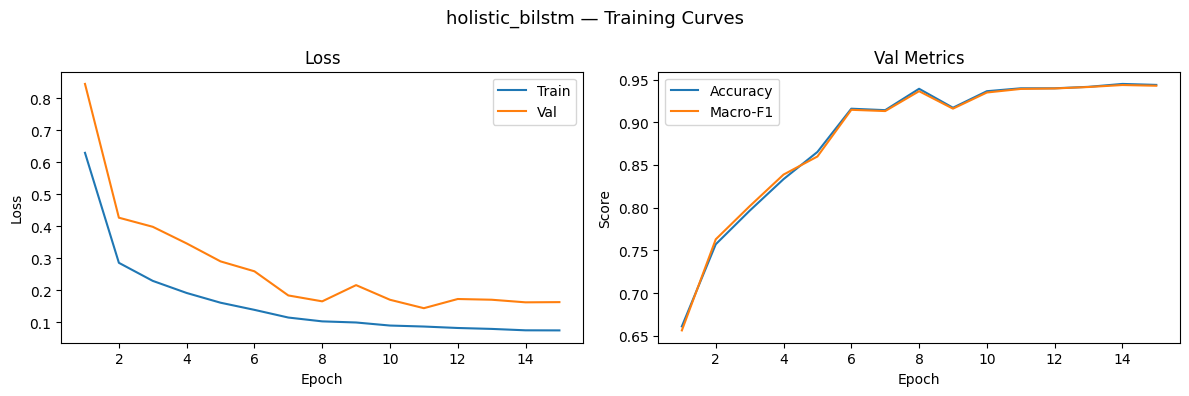

TEST  acc=0.9532  macro-F1=0.9536

Classification Report:
               precision    recall  f1-score   support

   entailment       0.89      0.94      0.91       172
contradiction       0.95      0.93      0.94       169
      neutral       0.99      1.00      0.99       171
    fake_drug       1.00      0.94      0.97       172

     accuracy                           0.95       684
    macro avg       0.95      0.95      0.95       684
 weighted avg       0.95      0.95      0.95       684



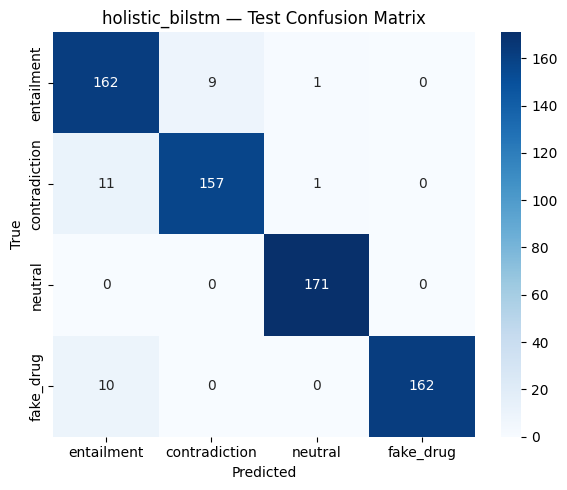

Predictions saved → holistic_bilstm_test_predictions.csv

Per-scenario accuracy:
scenario
contradiction    0.929
entailment       0.942
fake_drug        0.942
neutral          1.000
Name: correct, dtype: float64


In [22]:
holistic_bilstm_config = BiLSTMConfig(
    model_name="holistic_bilstm",
    data_prefix="holistic",
    max_len=128,
)
exp_3a = BiLSTMExperiment(holistic_bilstm_config).run()

## 3 · Experiment 3b — Holistic PubMedBERT

Fine-tunes BiomedNLP-BiomedBERT on full premise–hypothesis pairs. Truncation strategy is `only_second` — the premise is authoritative evidence and is never cut.

Train: 26749  Val: 1758  Test: 684

Train class dist:
scenario
neutral          931
entailment       930
contradiction    930
fake_drug        930
Name: count, dtype: int64


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect ide

Loaded microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext
Trainable parameters: 109,485,316
Train batches: 1672   Val batches: 110
Total steps: 8360   Warmup steps: 836
Epoch 01/5 | tr_loss=0.2824 tr_acc=0.900 | val_loss=0.1120 val_acc=0.969 val_F1=0.969 | 720.0s ← best
Epoch 02/5 | tr_loss=0.0597 tr_acc=0.985 | val_loss=0.1120 val_acc=0.979 val_F1=0.978 | 738.9s ← best
Epoch 03/5 | tr_loss=0.0317 tr_acc=0.993 | val_loss=0.1065 val_acc=0.982 val_F1=0.982 | 743.3s ← best
Epoch 04/5 | tr_loss=0.0183 tr_acc=0.996 | val_loss=0.1092 val_acc=0.984 val_F1=0.983 | 743.9s ← best
Epoch 05/5 | tr_loss=0.0110 tr_acc=0.997 | val_loss=0.1270 val_acc=0.983 val_F1=0.982 | 763.4s

Best val macro-F1: 0.9827


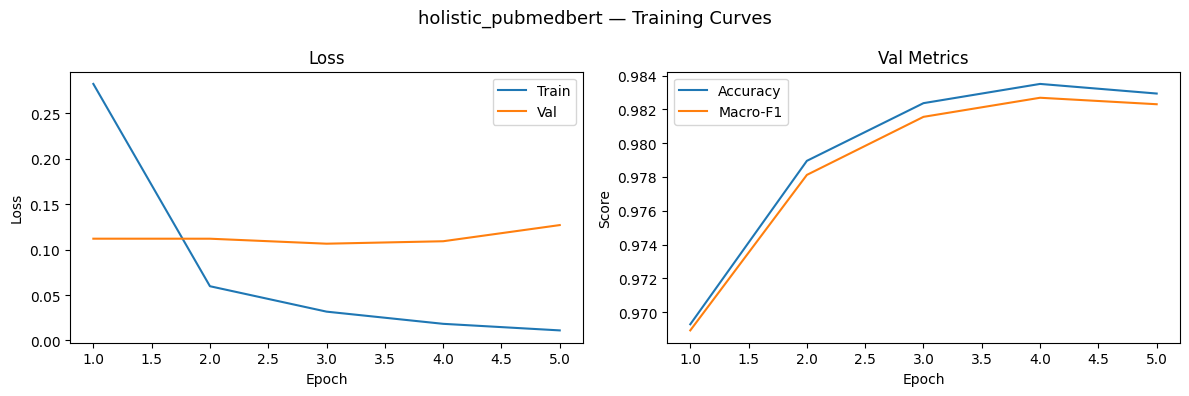

TEST  acc=0.9415  macro-F1=0.9407

Classification Report:
               precision    recall  f1-score   support

   entailment       0.98      0.78      0.87       172
contradiction       0.98      0.98      0.98       169
      neutral       0.99      1.00      1.00       171
    fake_drug       0.84      1.00      0.91       172

     accuracy                           0.94       684
    macro avg       0.95      0.94      0.94       684
 weighted avg       0.95      0.94      0.94       684



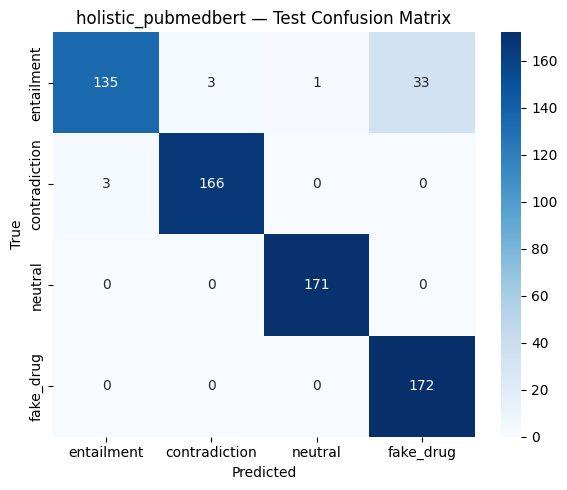

Predictions saved → holistic_pubmedbert_test_predictions.csv

Per-scenario accuracy:
scenario
contradiction    0.982
entailment       0.785
fake_drug        1.000
neutral          1.000
Name: correct, dtype: float64


In [10]:
holistic_bert_config = BERTConfig(
    model_name="holistic_pubmedbert",
    data_prefix="holistic",
    max_len=256,
    batch_size=16,   # reduce to 8 if OOM on GPU
)
exp_3b = BERTExperiment(holistic_bert_config).run()

## 4 · Experiment 3c — Atomic BiLSTM

Same Siamese BiLSTM architecture, trained on SDP-extracted triplet hypotheses instead of full responses. Predictions are aggregated back to response-level via `AtomicAggregator`.

Train: 2333  Val: 128  Test: 1047

Train class dist:
scenario
contradiction    1069
entailment        653
fake_drug         537
neutral            74
Name: count, dtype: int64

Neutral fraction in train: 3.2%
⚠ Neutral is severely underrepresented — class weighting applied.

Vocab: 5875   Embed matrix: (5875, 100)
Train batches: 37  Val batches: 2
Trainable parameters: 4,012,912
Class weights: { entailment: 0.343, contradiction: 0.210, neutral: 3.030, fake_drug: 0.417 }
Epoch 01/15 | tr_loss=1.3781 tr_acc=0.398 | val_loss=1.3592 val_acc=0.672 val_F1=0.246 | 1.5s ← best
Epoch 02/15 | tr_loss=1.2371 tr_acc=0.514 | val_loss=1.2875 val_acc=0.547 val_F1=0.346 | 1.3s ← best
Epoch 03/15 | tr_loss=1.0609 tr_acc=0.563 | val_loss=1.2746 val_acc=0.672 val_F1=0.467 | 1.3s ← best
Epoch 04/15 | tr_loss=0.8860 tr_acc=0.618 | val_loss=1.0987 val_acc=0.461 val_F1=0.461 | 1.3s
Epoch 05/15 | tr_loss=0.7249 tr_acc=0.643 | val_loss=1.1506 val_acc=0.680 val_F1=0.565 | 1.3s ← best
Epoch 06/15 | tr_loss=0.675

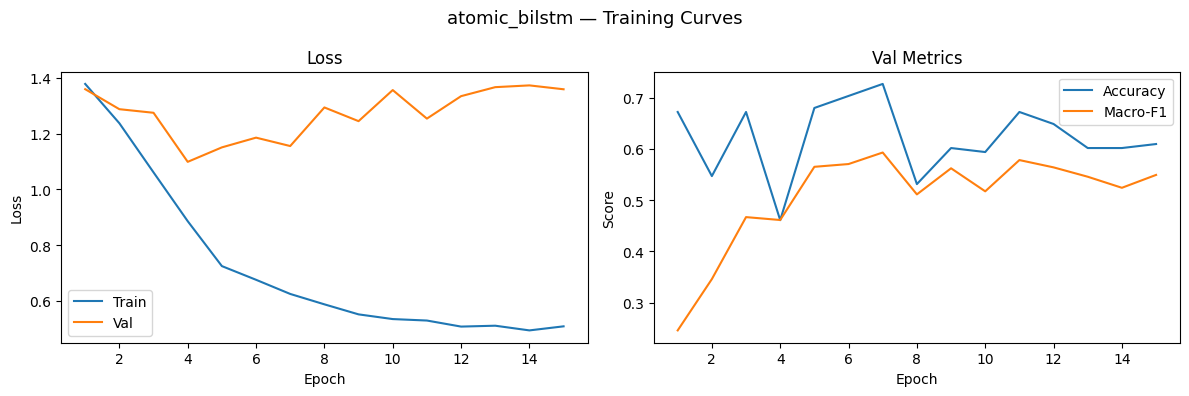

TRIPLET-LEVEL  acc=0.7202  macro-F1=0.5811

Classification Report:
               precision    recall  f1-score   support

   entailment       0.65      0.34      0.44        92
contradiction       0.73      0.93      0.82       619
      neutral       0.43      0.69      0.53        35
    fake_drug       0.78      0.41      0.53       301

     accuracy                           0.72      1047
    macro avg       0.65      0.59      0.58      1047
 weighted avg       0.73      0.72      0.70      1047



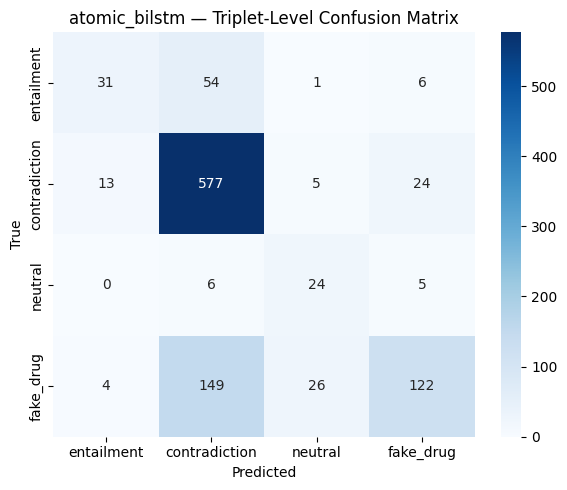

AGGREGATED (response-level)  acc=0.7945  macro-F1=0.5597
               precision    recall  f1-score   support

   entailment       0.63      0.29      0.40        59
contradiction       0.83      0.96      0.89       344
      neutral       0.81      0.69      0.75        32
    fake_drug       0.29      0.16      0.21        37

     accuracy                           0.79       472
    macro avg       0.64      0.52      0.56       472
 weighted avg       0.76      0.79      0.77       472



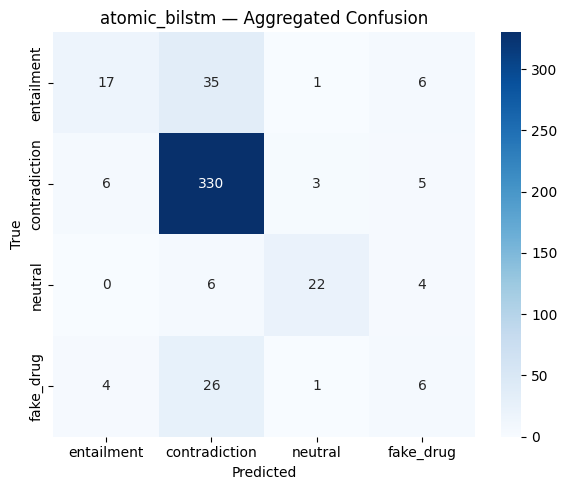


Saved triplet     → atomic_bilstm_triplet_predictions.csv
Saved aggregated  → atomic_bilstm_aggregated_predictions.csv
Avg triplets per response: 2.2
Per-scenario accuracy:
scenario
contradiction    0.959
entailment       0.288
fake_drug        0.162
neutral          0.688
Name: correct, dtype: float64


In [11]:
atomic_bilstm_config = BiLSTMConfig(
    model_name="atomic_bilstm",
    data_prefix="atomic",
    max_len=64,   # atomic hypotheses are ~10 words
)
exp_3c = BiLSTMExperiment(atomic_bilstm_config).run()

## 5 · Experiment 3d — Atomic PubMedBERT

Fine-tunes PubMedBERT on the same atomic triplets — shorter inputs than the holistic model, so truncation risk is much lower.

Train: 2333  Val: 128  Test: 1047

Train class dist:
scenario
contradiction    1069
entailment        653
fake_drug         537
neutral            74
Name: count, dtype: int64

Neutral fraction in train: 3.2%
⚠ Neutral is severely underrepresented — class weighting applied.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect ide

Loaded microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext
Trainable parameters: 109,485,316
Train batches: 73   Val batches: 4
Total steps: 365   Warmup steps: 36
Epoch 01/5 | tr_loss=1.0129 tr_acc=0.583 | val_loss=0.7924 val_acc=0.688 val_F1=0.249 | 31.6s ← best
Epoch 02/5 | tr_loss=0.6148 tr_acc=0.785 | val_loss=0.7786 val_acc=0.703 val_F1=0.313 | 32.0s ← best
Epoch 03/5 | tr_loss=0.4745 tr_acc=0.834 | val_loss=0.8305 val_acc=0.625 val_F1=0.292 | 31.8s
Epoch 04/5 | tr_loss=0.3798 tr_acc=0.870 | val_loss=0.7769 val_acc=0.727 val_F1=0.511 | 32.3s ← best
Epoch 05/5 | tr_loss=0.3360 tr_acc=0.896 | val_loss=0.7987 val_acc=0.734 val_F1=0.518 | 32.4s ← best

Best val macro-F1: 0.5184


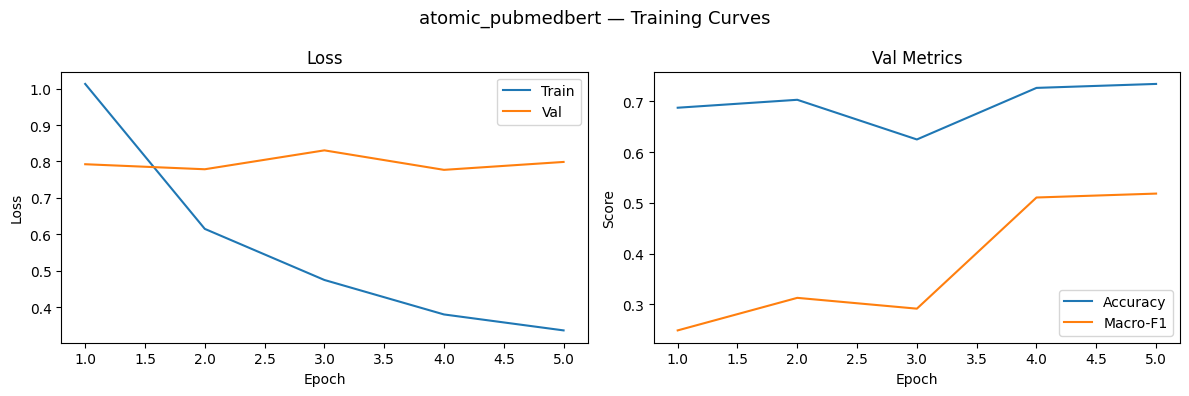

TRIPLET-LEVEL  acc=0.8902  macro-F1=0.6917

Classification Report:
               precision    recall  f1-score   support

   entailment       0.58      0.66      0.62        92
contradiction       0.91      0.96      0.94       619
      neutral       0.86      0.17      0.29        35
    fake_drug       0.95      0.90      0.93       301

     accuracy                           0.89      1047
    macro avg       0.83      0.67      0.69      1047
 weighted avg       0.89      0.89      0.88      1047



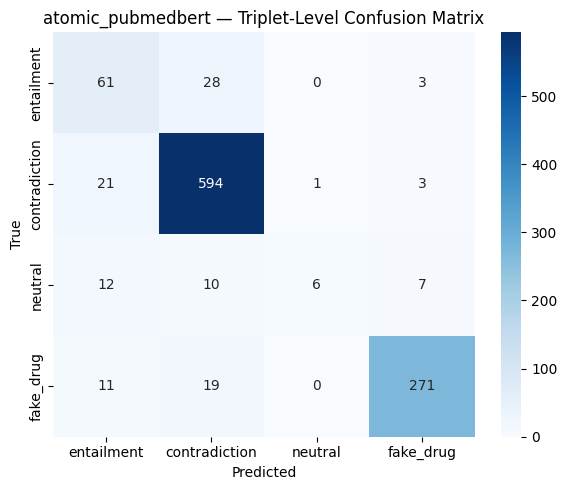

AGGREGATED  acc=0.8559  macro-F1=0.6416
               precision    recall  f1-score   support

   entailment       0.62      0.56      0.59        59
contradiction       0.90      0.99      0.94       344
      neutral       1.00      0.19      0.32        32
    fake_drug       0.74      0.70      0.72        37

     accuracy                           0.86       472
    macro avg       0.82      0.61      0.64       472
 weighted avg       0.86      0.86      0.84       472



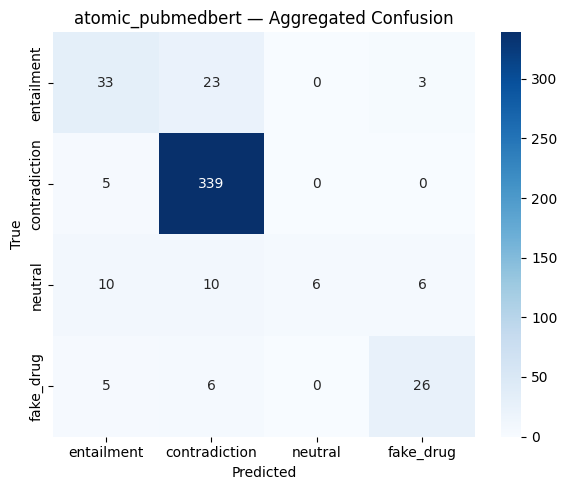

Saved triplet + aggregated predictions.


In [12]:
atomic_bert_config = BERTConfig(
    model_name="atomic_pubmedbert",
    data_prefix="atomic",
    max_len=128,   # shorter than holistic — atomic hypotheses are brief
    batch_size=32,
)
exp_3d = BERTExperiment(atomic_bert_config).run()

## 6 · Results Comparison — 2×2 Grid

Loads all four prediction files and produces:
- 2×2 metric summary table
- Per-class F1 breakdown (all 4 scenarios)
- Side-by-side confusion matrices
- McNemar's test for pairwise statistical significance
- Aggregation quality analysis (atomic models)
- Cross-model error analysis

In [13]:
class ResultsComparator:
    """Loads the four models' prediction CSVs and runs the full 2×2 comparison."""

    def __init__(self, files: dict, classes=CLASSES):
        self.files      = files
        self.classes    = classes
        self.preds_all  = {}

    def load(self):
        for name, path in self.files.items():
            df = pd.read_csv(path)
            self.preds_all[name] = df
            print(f"Loaded {name:25s} — {len(df)} rows  ({path})")
        return self

    def summary_table(self):
        rows = []
        for name, df in self.preds_all.items():
            y_true, y_pred = df['true_label'], df['pred_label']
            row = {
                "Model":    name,
                "Accuracy": round(accuracy_score(y_true, y_pred), 4),
                "Macro-F1": round(f1_score(y_true, y_pred, average='macro', zero_division=0), 4),
                "MCC":      round(matthews_corrcoef(y_true, y_pred), 4),
            }
            per_class = f1_score(y_true, y_pred, average=None, zero_division=0)
            for i, cls in enumerate(self.classes):
                row[f"F1_{cls}"] = round(per_class[i], 4) if i < len(per_class) else 0.0
            rows.append(row)

        self.summary = pd.DataFrame(rows).set_index("Model")
        print("=" * 80); print("2×2 EXPERIMENT RESULTS"); print("=" * 80)
        print(self.summary.to_string())
        return self

    def plot_grid(self):
        grid = pd.DataFrame({
            "BiLSTM":     [self.summary.loc["Holistic BiLSTM", "Macro-F1"],
                           self.summary.loc["Atomic BiLSTM",   "Macro-F1"]],
            "PubMedBERT": [self.summary.loc["Holistic PubMedBERT", "Macro-F1"],
                           self.summary.loc["Atomic PubMedBERT",   "Macro-F1"]],
        }, index=["Holistic", "Atomic"])

        fig, ax = plt.subplots(figsize=(5, 3))
        sns.heatmap(grid, annot=True, fmt=".4f", cmap="YlGnBu", vmin=0, vmax=1,
                    linewidths=0.5, ax=ax, cbar_kws={"label": "Macro-F1"})
        ax.set_title("2×2 Macro-F1 Grid", fontsize=13, fontweight='bold')
        ax.set_xlabel("Model Architecture"); ax.set_ylabel("Granularity")
        plt.tight_layout(); plt.savefig("results_2x2_grid.png", dpi=150); plt.show()
        return self

    def plot_perclass_bars(self):
        class_cols       = [f"F1_{c}" for c in self.classes]
        bar_df           = self.summary[class_cols].T
        bar_df.index     = self.classes

        fig, ax = plt.subplots(figsize=(11, 5))
        x    = np.arange(len(self.classes))
        w    = 0.2
        cols = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
        for i, (model, color) in enumerate(zip(bar_df.columns, cols)):
            ax.bar(x + i * w, bar_df[model], w, label=model, color=color, alpha=0.85)
        ax.set_xticks(x + w * 1.5)
        ax.set_xticklabels(self.classes, fontsize=11)
        ax.set_ylim(0, 1.05)
        ax.set_ylabel("F1 Score"); ax.set_title("Per-Class F1 by Model", fontsize=13)
        ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
        plt.tight_layout(); plt.savefig("results_perclass_f1.png", dpi=150); plt.show()
        return self

    def plot_confusions(self):
        fig, axes = plt.subplots(2, 2, figsize=(14, 11))
        for ax, name in zip(axes.flat, self.preds_all.keys()):
            df = self.preds_all[name]
            cm = confusion_matrix(df['true_label'], df['pred_label'])
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                        xticklabels=self.classes, yticklabels=self.classes, ax=ax, cbar=False)
            ax.set_title(name, fontsize=11, fontweight='bold')
            ax.set_xlabel("Predicted"); ax.set_ylabel("True")
        plt.suptitle("Confusion Matrices — All 4 Models", fontsize=14, fontweight='bold', y=1.01)
        plt.tight_layout(); plt.savefig("results_confusion_matrices.png", dpi=150); plt.show()
        return self

    @staticmethod
    def _mcnemar_test(y_true, y_pred1, y_pred2):
        """Continuity-corrected McNemar's test. b/c = model1/2 uniquely correct."""
        b = sum(1 for yt, yp1, yp2 in zip(y_true, y_pred1, y_pred2) if yp1 == yt and yp2 != yt)
        c = sum(1 for yt, yp1, yp2 in zip(y_true, y_pred1, y_pred2) if yp1 != yt and yp2 == yt)
        if (b + c) == 0:
            return float('nan'), float('nan')
        stat = (abs(b - c) - 1) ** 2 / (b + c)
        p    = 1 - chi2.cdf(stat, df=1)
        return round(stat, 3), round(p, 4)

    def mcnemar_pairs(self):
        names = list(self.preds_all.keys())
        print(f"{'Pair':55s}  {'χ²':>6}  {'p-value':>8}  Sig?")
        print("─" * 80)
        for i in range(len(names)):
            for j in range(i + 1, len(names)):
                n1, n2 = names[i], names[j]
                d1 = self.preds_all[n1].set_index(['original_id', 'scenario'])
                d2 = self.preds_all[n2].set_index(['original_id', 'scenario'])
                shared = d1.index.intersection(d2.index)
                if len(shared) < 20:
                    print(f"  {n1} vs {n2}: insufficient shared rows ({len(shared)})")
                    continue
                yt  = d1.loc[shared, 'true_label'].tolist()
                yp1 = d1.loc[shared, 'pred_label'].tolist()
                yp2 = d2.loc[shared, 'pred_label'].tolist()
                stat, p = self._mcnemar_test(yt, yp1, yp2)
                sig = "✓" if isinstance(p, float) and p < 0.05 else " "
                print(f"  {n1:25s} vs {n2:25s}  {stat:>6}  {p:>8}  {sig}")
        return self

    def aggregation_quality(self):
        for name in ["Atomic BiLSTM", "Atomic PubMedBERT"]:
            df = self.preds_all.get(name)
            if df is None or 'n_triplets' not in df.columns:
                continue
            print(f"\n{name} — Triplets-per-response distribution:")
            print(df['n_triplets'].describe())
            df = df.copy()
            df['triplet_bin'] = pd.cut(df['n_triplets'], bins=[0, 1, 3, 6, 100],
                                        labels=['1', '2-3', '4-6', '7+'])
            print("\nAccuracy by number of triplets:")
            print(df.groupby('triplet_bin')['correct'].agg(['mean', 'count']).round(3))
        return self

    def error_analysis(self):
        keyed = {name: df for name, df in self.preds_all.items() if 'original_id' in df.columns}
        if not keyed:
            print("No models expose 'original_id' — skipping error analysis.")
            return self

        first_name, first_df = next(iter(keyed.items()))
        all_wrong_keys = set(
            first_df.set_index(['original_id', 'scenario'])[~first_df['correct'].values].index.tolist()
        )
        for name, df in keyed.items():
            wrong = set(df.set_index(['original_id', 'scenario'])[~df['correct'].values].index.tolist())
            all_wrong_keys &= wrong

        print(f"Responses all {len(keyed)} models get wrong: {len(all_wrong_keys)}")
        if all_wrong_keys and 'premise' in first_df.columns:
            examples = first_df.set_index(['original_id', 'scenario'])
            hard = examples.loc[list(all_wrong_keys)[:5], ['premise', 'scenario']]
            print("\nExamples:")
            for _, row in hard.iterrows():
                print(f"  [{row['scenario']}] {str(row['premise'])[:100]}...")
        return self

    def export(self):
        print("\n" + "=" * 80)
        print("FINAL RESULTS SUMMARY")
        print("=" * 80)
        print(self.summary.to_string())
        self.summary.to_csv("results_final_summary.csv")
        print("\nSaved → results_final_summary.csv")
        print("Saved → results_2x2_grid.png")
        print("Saved → results_perclass_f1.png")
        print("Saved → results_confusion_matrices.png")
        return self

    def run_all(self):
        return (self.load().summary_table().plot_grid().plot_perclass_bars()
                    .plot_confusions().mcnemar_pairs().aggregation_quality()
                    .error_analysis().export())

Loaded Holistic BiLSTM           — 684 rows  (holistic_bilstm_test_predictions.csv)
Loaded Holistic PubMedBERT       — 684 rows  (holistic_pubmedbert_test_predictions.csv)
Loaded Atomic BiLSTM             — 472 rows  (atomic_bilstm_aggregated_predictions.csv)
Loaded Atomic PubMedBERT         — 472 rows  (atomic_pubmedbert_aggregated_predictions.csv)
2×2 EXPERIMENT RESULTS
                     Accuracy  Macro-F1     MCC  F1_entailment  F1_contradiction  F1_neutral  F1_fake_drug
Model                                                                                                     
Holistic BiLSTM        0.9532    0.9536  0.9379         0.9127            0.9373      0.9942        0.9701
Holistic PubMedBERT    0.9415    0.9407  0.9250         0.8710            0.9822      0.9971        0.9125
Atomic BiLSTM          0.7945    0.5597  0.4710         0.3953            0.8907      0.7458        0.2069
Atomic PubMedBERT      0.8559    0.6416  0.6482         0.5893            0.9391      0.31

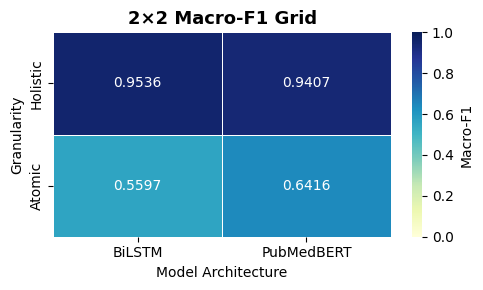

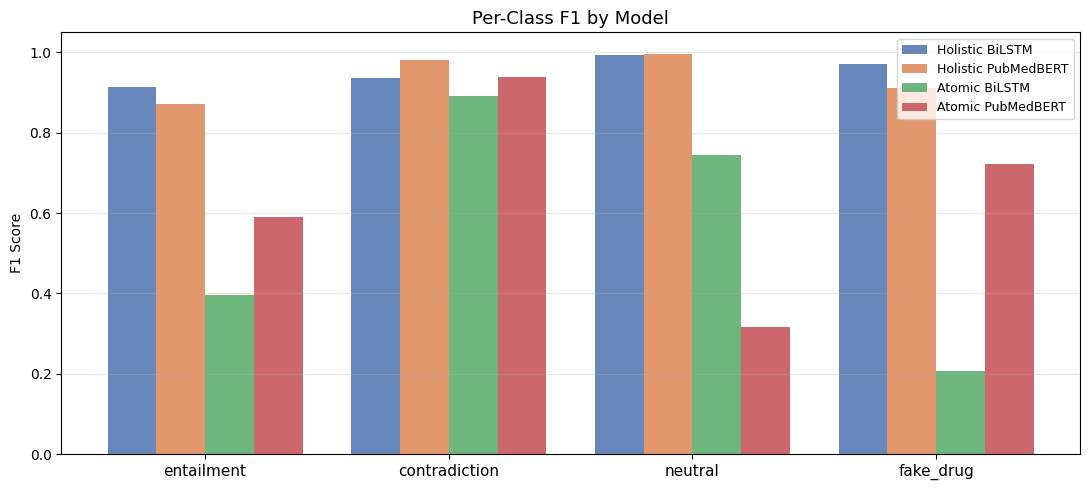

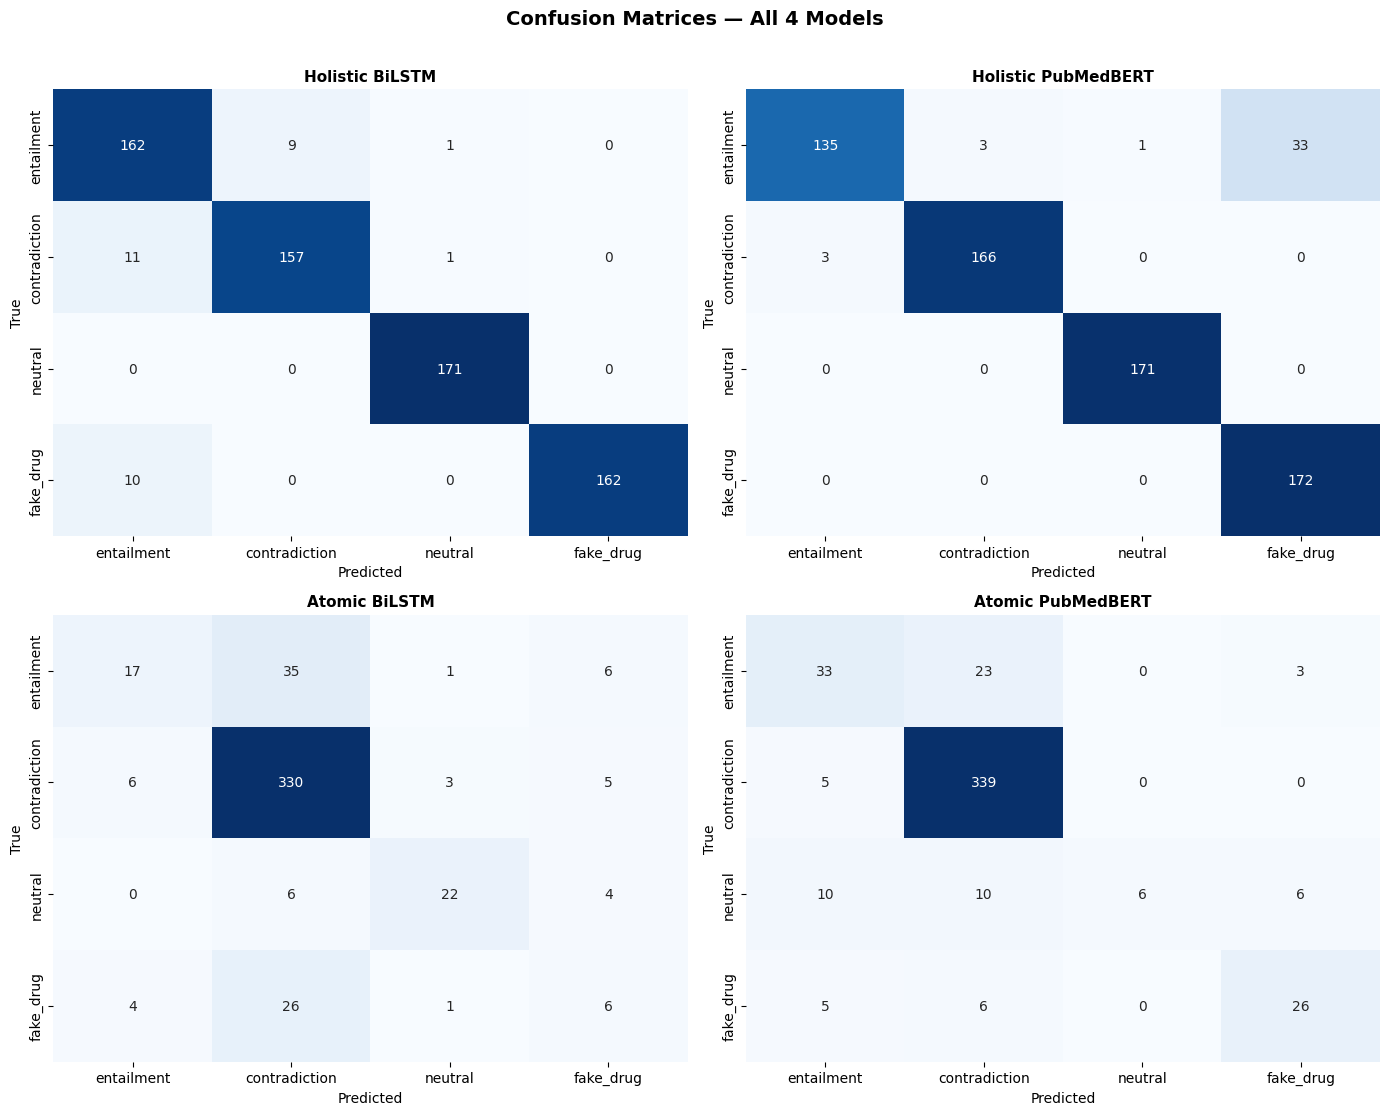

Pair                                                         χ²   p-value  Sig?
────────────────────────────────────────────────────────────────────────────────
  Holistic BiLSTM           vs Holistic PubMedBERT         0.817    0.3662   
  Holistic BiLSTM           vs Atomic BiLSTM                 3.5    0.0614   
  Holistic BiLSTM           vs Atomic PubMedBERT           2.769    0.0961   
  Holistic PubMedBERT       vs Atomic BiLSTM               7.692    0.0055  ✓
  Holistic PubMedBERT       vs Atomic PubMedBERT             8.1    0.0044  ✓
  Atomic BiLSTM             vs Atomic PubMedBERT           8.809     0.003  ✓

Atomic BiLSTM — Triplets-per-response distribution:
count    472.000000
mean       2.218220
std        2.472148
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max       20.000000
Name: n_triplets, dtype: float64

Accuracy by number of triplets:
              mean  count
triplet_bin              
1            0.764    254
2-3          0

In [14]:
prediction_files = {
    "Holistic BiLSTM":     "holistic_bilstm_test_predictions.csv",
    "Holistic PubMedBERT": "holistic_pubmedbert_test_predictions.csv",
    "Atomic BiLSTM":       "atomic_bilstm_aggregated_predictions.csv",
    "Atomic PubMedBERT":   "atomic_pubmedbert_aggregated_predictions.csv",
}
comparator = ResultsComparator(prediction_files).run_all()